Extracting EDF parameters from /kaggle/input/datasets/alphajr7/mdd-patients-eeg-dataset/MDD S29 TASK.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 161535  =      0.000 ...   630.996 secs...


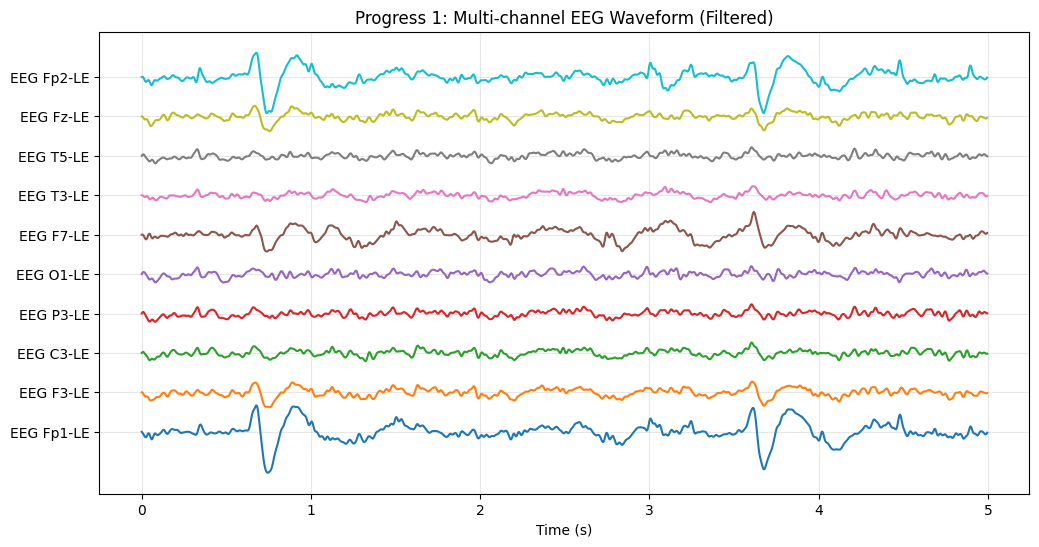

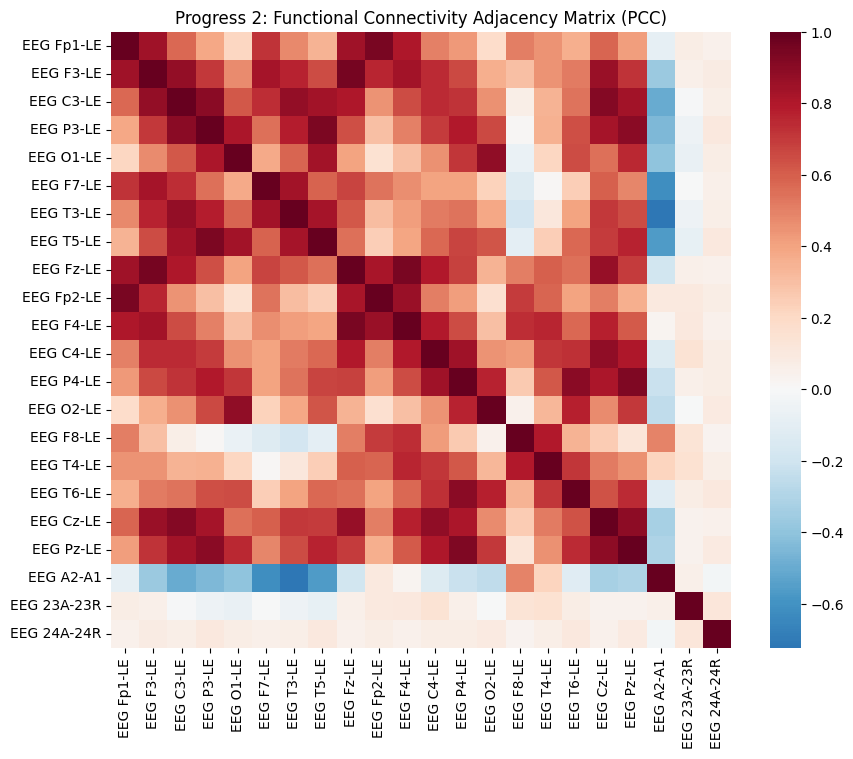

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


<Figure size 1000x500 with 0 Axes>

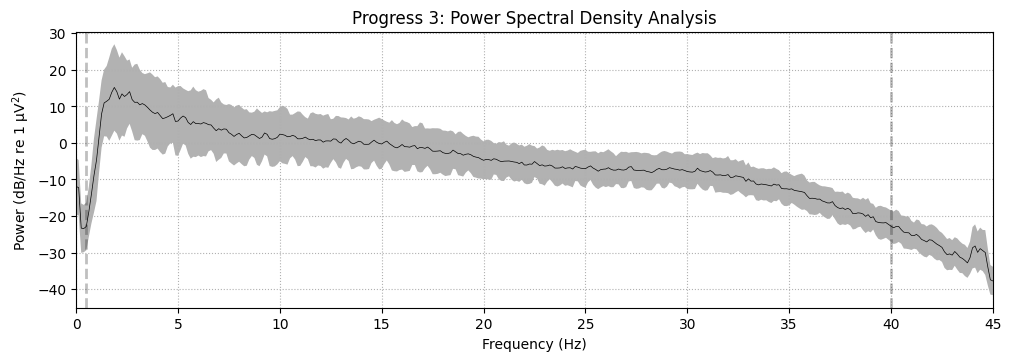

✅ 三张图已全部生成！请检查上方输出区域，并从 Output 栏下载。


In [6]:
import mne
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 设置路径
path = '/kaggle/input/datasets/alphajr7/mdd-patients-eeg-dataset'
file_name = 'MDD S29 TASK.edf'
full_path = os.path.join(path, file_name)

# 2. 读取 & 0.5-40Hz 滤波
raw = mne.io.read_raw_edf(full_path, preload=True)
raw.filter(l_freq=0.5, h_freq=40.0, verbose=False)

# ==========================================
# Progress 1: 原始波形 (强制渲染版)
# ==========================================
# 选前 10 个通道，展示 5 秒数据
data_plot, times = raw.get_data(stop=int(raw.info['sfreq']*5), return_times=True)
plt.figure(figsize=(12, 6))
for i in range(10): # 只画前10个通道
    plt.plot(times, data_plot[i] + i * 100e-6) # 加上偏置防止重叠
plt.yticks(np.arange(10)*100e-6, raw.ch_names[:10])
plt.title("Progress 1: Multi-channel EEG Waveform (Filtered)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.savefig('1_raw_wave.png', dpi=300)
plt.show() # 强制在屏幕显示

# ==========================================
# Progress 2: 邻接矩阵 (脑网络图谱)
# ==========================================
# 计算前 30 个通道的相关性
corr_matrix = np.corrcoef(data_plot[:30, :])
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, 
            xticklabels=raw.ch_names[:30], yticklabels=raw.ch_names[:30])
plt.title("Progress 2: Functional Connectivity Adjacency Matrix (PCC)")
plt.savefig('2_connectivity_matrix.png', dpi=300)
plt.show()

# ==========================================
# Progress 3: 功率谱密度 (频域分析)
# ==========================================
plt.figure(figsize=(10, 5))
# 使用 MNE 内置的 PSD 计算
psd_fig = raw.compute_psd(fmax=45).plot(average=True, spatial_colors=True, show=False)
plt.title("Progress 3: Power Spectral Density Analysis")
plt.savefig('3_psd_analysis.png', dpi=300)
plt.show()

print("✅ 三张图已全部生成！请检查上方输出区域，并从 Output 栏下载。")

Extracting EDF parameters from /kaggle/input/datasets/alphajr7/mdd-patients-eeg-dataset/H S29 TASK.edf...
Setting channel info structure...
Creating raw.info structure...
Reading 0 ... 154879  =      0.000 ...   604.996 secs...


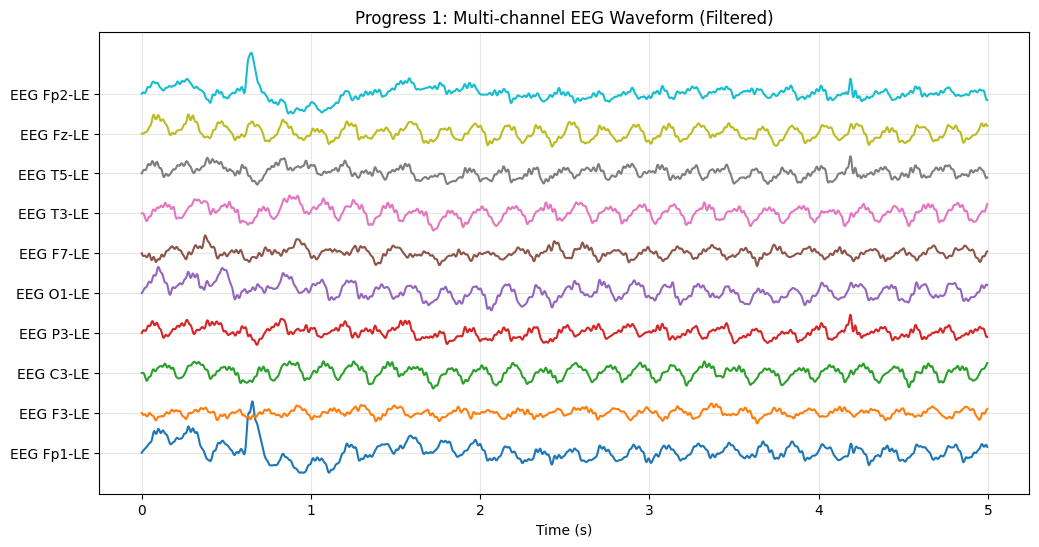

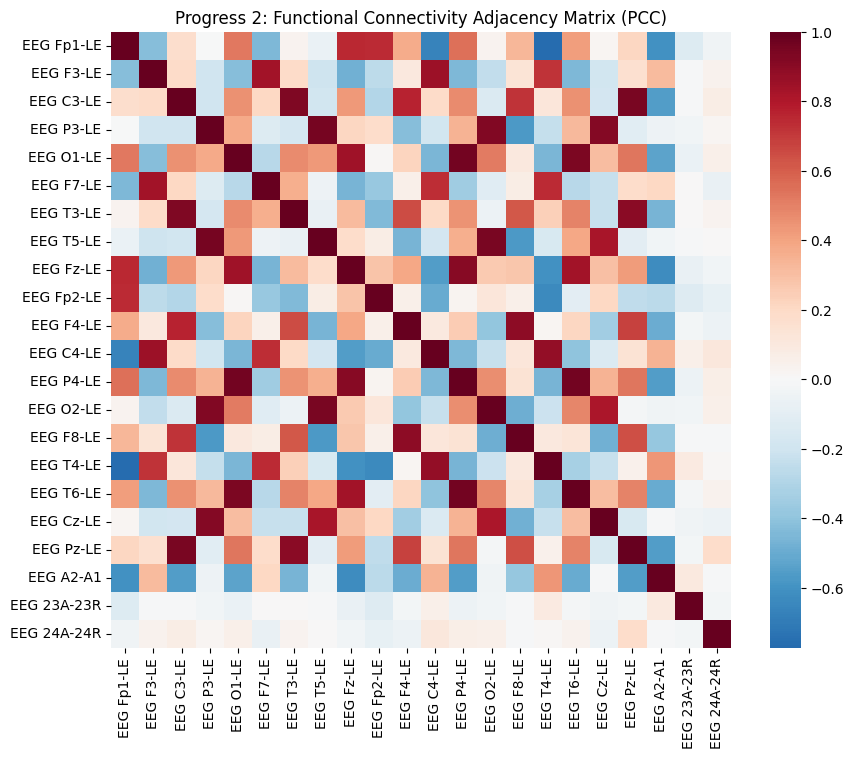

Effective window size : 8.000 (s)
Plotting power spectral density (dB=True).


<Figure size 1000x500 with 0 Axes>

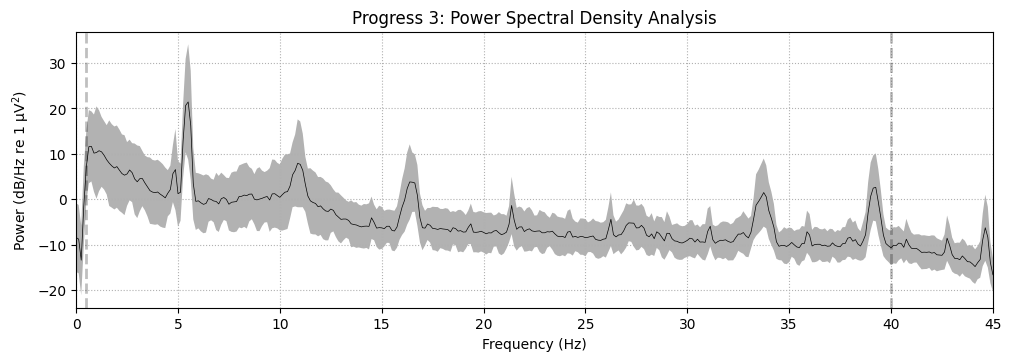

✅ 三张图已全部生成！请检查上方输出区域，并从 Output 栏下载。


In [7]:
import mne
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 设置路径
path = '/kaggle/input/datasets/alphajr7/mdd-patients-eeg-dataset'
file_name = 'H S29 TASK.edf'
full_path = os.path.join(path, file_name)

# 2. 读取 & 0.5-40Hz 滤波
raw = mne.io.read_raw_edf(full_path, preload=True)
raw.filter(l_freq=0.5, h_freq=40.0, verbose=False)

# ==========================================
# Progress 1: 原始波形 (强制渲染版)
# ==========================================
# 选前 10 个通道，展示 5 秒数据
data_plot, times = raw.get_data(stop=int(raw.info['sfreq']*5), return_times=True)
plt.figure(figsize=(12, 6))
for i in range(10): # 只画前10个通道
    plt.plot(times, data_plot[i] + i * 100e-6) # 加上偏置防止重叠
plt.yticks(np.arange(10)*100e-6, raw.ch_names[:10])
plt.title("Progress 1: Multi-channel EEG Waveform (Filtered)")
plt.xlabel("Time (s)")
plt.grid(True, alpha=0.3)
plt.savefig('1_raw_wave.png', dpi=300)
plt.show() # 强制在屏幕显示

# ==========================================
# Progress 2: 邻接矩阵 (脑网络图谱)
# ==========================================
# 计算前 30 个通道的相关性
corr_matrix = np.corrcoef(data_plot[:30, :])
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap='RdBu_r', center=0, 
            xticklabels=raw.ch_names[:30], yticklabels=raw.ch_names[:30])
plt.title("Progress 2: Functional Connectivity Adjacency Matrix (PCC)")
plt.savefig('2_connectivity_matrix.png', dpi=300)
plt.show()

# ==========================================
# Progress 3: 功率谱密度 (频域分析)
# ==========================================
plt.figure(figsize=(10, 5))
# 使用 MNE 内置的 PSD 计算
psd_fig = raw.compute_psd(fmax=45).plot(average=True, spatial_colors=True, show=False)
plt.title("Progress 3: Power Spectral Density Analysis")
plt.savefig('3_psd_analysis.png', dpi=300)
plt.show()

print("✅ 三张图已全部生成！请检查上方输出区域，并从 Output 栏下载。")

In [8]:
import mne
import os
import numpy as np

# 1. 路径与样本设置
path = '/kaggle/input/datasets/alphajr7/mdd-patients-eeg-dataset'
mdd_file = 'MDD S29 TASK.edf'  # 实验组
hc_file = 'H S29 TASK.edf'      # 对照组 (Healthy Control)

def get_deep_stats(file_name):
    full_path = os.path.join(path, file_name)
    raw = mne.io.read_raw_edf(full_path, preload=True, verbose=False)
    raw.filter(0.5, 40.0, verbose=False)
    data = raw.get_data()
    ch_names = raw.ch_names
    
    # --- 时域：平均波动幅度 ---
    rms = np.mean(np.sqrt(np.mean(data**2, axis=1))) * 1e6
    
    # --- 空域：相关性矩阵 (Progress 2 的底层数据) ---
    corr_matrix = np.corrcoef(data)
    # 计算网络密度：相关性高于 0.6 的强连接比例
    density = np.sum(np.abs(corr_matrix) > 0.6) / (corr_matrix.size)
    avg_conn = np.mean(np.abs(corr_matrix))
    
    # --- 频域：功率谱 (Progress 3 的底层数据) ---
    psds, freqs = raw.compute_psd(fmin=0.5, fmax=40, verbose=False).get_data(return_freqs=True)
    def band_p(fmin, fmax):
        return psds[:, (freqs >= fmin) & (freqs <= fmax)].mean(axis=1)
    
    alpha = band_p(8, 13)
    total = psds.mean(axis=1)
    alpha_rel = np.mean(alpha / total) # Alpha 相对能量
    
    # 额叶不对称性 FAA 计算 (Fp2 - Fp1)
    try:
        f1, f2 = ch_names.index('EEG Fp1-LE'), ch_names.index('EEG Fp2-LE')
        faa = np.log(alpha[f2]) - np.log(alpha[f1])
    except:
        faa = None
        
    return {"rms": rms, "density": density, "avg_conn": avg_conn, "alpha_rel": alpha_rel, "faa": faa}

# 执行计算
mdd_stats = get_deep_stats(mdd_file)
hc_stats = get_deep_stats(hc_file)

# ==========================================
# 📊 核心数据对比报告
# ==========================================
print("\n" + "平衡对比分析报告".center(40, '='))
print(f"{'指标名称':<15} | {'MDD 组':<10} | {'Healthy 组':<10} | {'差异率'}")
print("-" * 50)

def print_row(name, m_val, h_val, unit=""):
    diff = ((m_val - h_val) / h_val) * 100
    print(f"{name:<15} | {m_val:>8.3f}{unit} | {h_val:>8.3f}{unit} | {diff:>+6.1f}%")

print_row("平均振幅", mdd_stats['rms'], hc_stats['rms'], "uV")
print_row("网络连接密度", mdd_stats['density'], hc_stats['density'])
print_row("平均连接强度", mdd_stats['avg_conn'], hc_stats['avg_conn'])
print_row("Alpha 能量比", mdd_stats['alpha_rel'], hc_stats['alpha_rel'])
if mdd_stats['faa'] is not None:
    print(f"{'额叶不对称性':<15} | {mdd_stats['faa']:>10.4f} | {hc_stats['faa']:>10.4f} | (数值越小抑郁倾向越重)")
print("=" * 50)


================平衡对比分析报告================
指标名称            | MDD 组      | Healthy 组  | 差异率
--------------------------------------------------
平均振幅            |   12.835uV |   12.337uV |   +4.0%
网络连接密度          |    0.682 |    0.169 | +302.4%
平均连接强度          |    0.631 |    0.327 |  +93.2%
Alpha 能量比       |    0.758 |    0.733 |   +3.4%
额叶不对称性          |    -0.2198 |     0.3845 | (数值越小抑郁倾向越重)
